## 1. Data Exploration | Sherry

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Data/top_50_stocks_data_formatted.csv')

## 2. Model Enhancement | Felix


Processing AAPL...
MAPE for AAPL: 1.31%


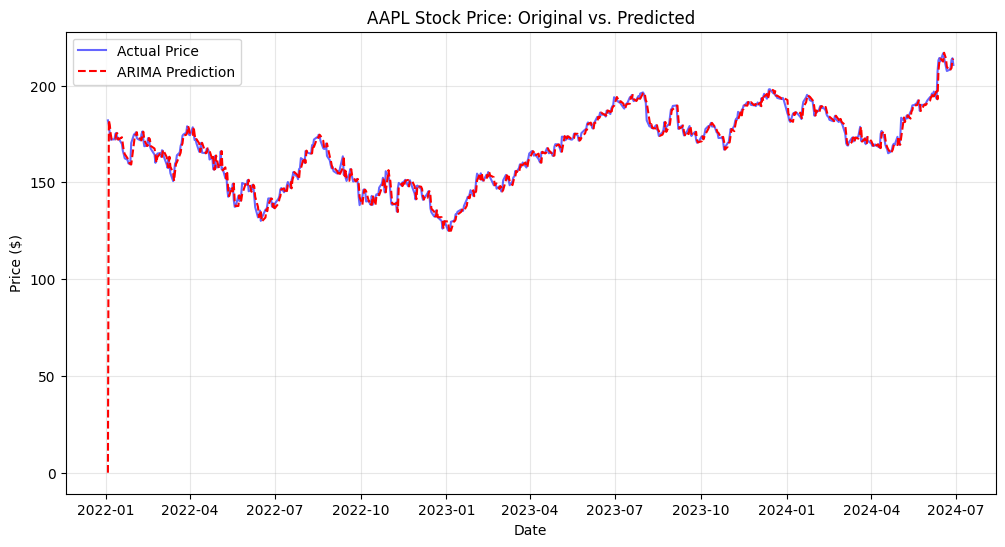


Processing TSLA...
MAPE for TSLA: 2.78%


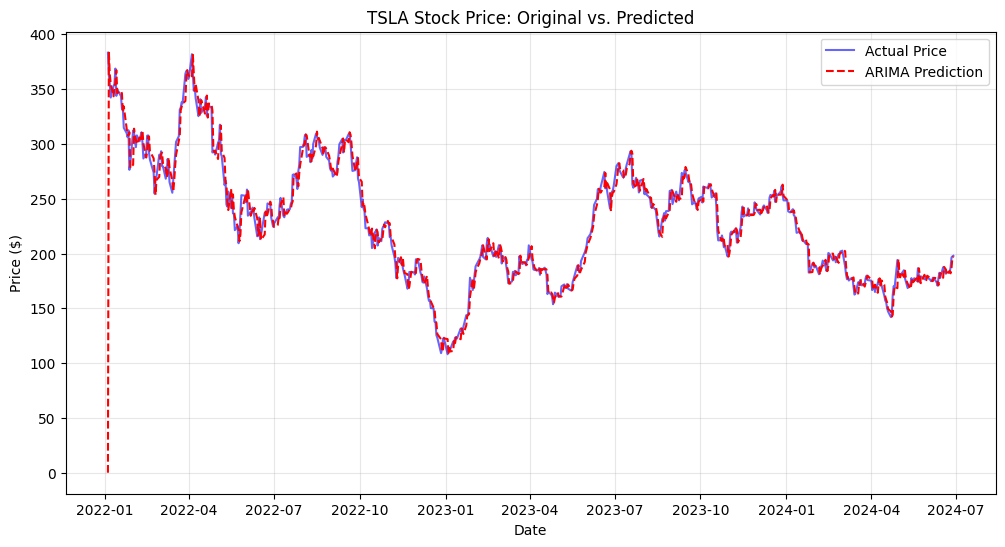


Processing MSFT...
MAPE for MSFT: 1.35%


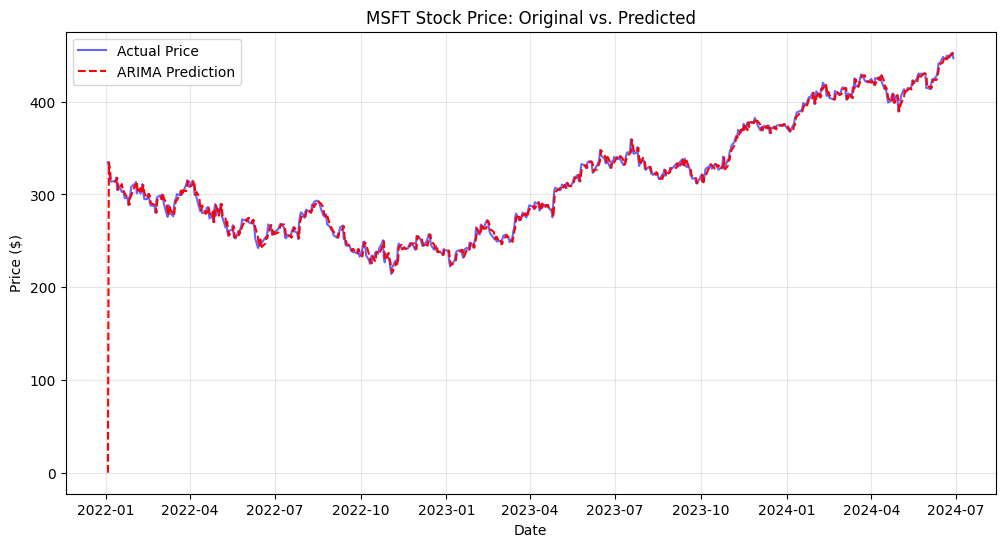


Processing AMZN...
MAPE for AMZN: 1.81%


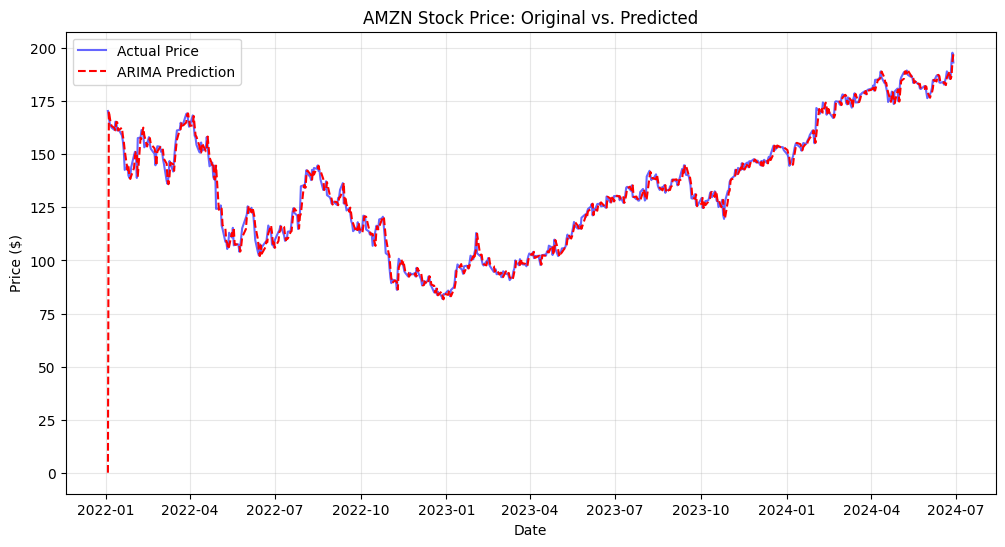

In [20]:
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error
import warnings

warnings.filterwarnings("ignore")

def process_stock_data(ticker_symbol, start, end, csv_file='/content/drive/MyDrive/Data/top_50_stocks_data_formatted.csv'):
    """
    Reads the CSV and filters for the specific ticker and date range.
    Expected CSV columns: Ticker, Date, Close
    """
    df = pd.read_csv(csv_file)
    # Convert Date to datetime object
    df['Date'] = pd.to_datetime(df['Date'])

    # Filter by ticker and date
    mask = (
        (df['Ticker'] == ticker_symbol) &
        (df['Date'] >= start) &
        (df['Date'] <= end)
    )
    ticker_df = df.loc[mask].sort_values('Date')
    #Outlier Detection
    Q1 = ticker_df['Close'].quantile(0.25)
    Q3 = ticker_df['Close'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
 # Remove outliers
    ticker_df = ticker_df[
        (ticker_df['Close'] >= lower_bound) &
        (ticker_df['Close'] <= upper_bound)
    ]
    # Set Date as index
    ticker_df.set_index('Date', inplace=True)

    return ticker_df['Close']


def arima_model(data, order=(5, 1, 0)):
    """
    Fits ARIMA model and returns predictions.
    Default order (5,1,0) is common for daily stock data.
    """
    # Fit ARIMA and get fitted values (in-sample)
    model = ARIMA(data, order=order)
    model_fit = model.fit()

    # Return fitted values for comparison
    return model_fit.fittedvalues

def compute_mape(actual, predicted):
    """
    Computes the Mean Absolute Percentage Error.
    """
    # Filter out the first element because differencing (d=1) creates a 0/NaN there
    return np.round(mean_absolute_percentage_error(actual[1:], predicted[1:]) * 100, 2)

def plot_data(actual, predicted, title):
    """
    Plots the actual vs predicted values.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(actual, label='Actual Price', color='blue', alpha=0.6)
    plt.plot(predicted, label='ARIMA Prediction', color='red', linestyle='--')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- MAIN EXECUTION LOOP ---
tickers = ['AAPL', 'TSLA', 'MSFT', 'AMZN']

# Adjusting dates based on your actual CSV bounds ('2022-01-03' to '2024-06-28')
start_date = '2022-01-03'
end_date = '2024-06-28'

for ticker in tickers:
    try:
        print(f"\nProcessing {ticker}...")

        # Step 1: Get closing prices
        closing_prices = process_stock_data(ticker, start_date, end_date)

        if closing_prices.empty:
            print(f"No data found for {ticker}")
            continue

        # Step 2: Fit ARIMA model and get predictions
        predictions = arima_model(closing_prices)

        # Step 3: Compute MAPE
        mape = compute_mape(closing_prices, predictions)
        print(f"MAPE for {ticker}: {mape}%")

        # Step 4: Plot actual vs. predicted
        plot_data(closing_prices, predictions, f'{ticker} Stock Price: Original vs. Predicted')

    except Exception as e:
        print(f"Error processing {ticker}: {e}")

## 4. Innovation

Source:

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf

def update_portfolio_live(portfolio_df, tickers):
    """
    Downloads live data for specified tickers, calculates current metrics,
    and updates their rows in the summarized portfolio DataFrame.
    """
    print(f"--- Fetching live market data for: {tickers} ---")

    #downloading past prices
    live_data = yf.download(tickers, period="1y", progress=False)

    #handling the single ticker downloads vs the multiple tickers
    if len(tickers) == 1:
        close_prices = live_data['Adj Close'] if 'Adj Close' in live_data else live_data['Close']
        live_df = pd.DataFrame({tickers[0]: close_prices})
    else:
        live_df = live_data['Adj Close'] if 'Adj Close' in live_data else live_data['Close']
    #recalculating the metrics
    for ticker in live_df.columns:
        prices = live_df[ticker].dropna()
        if len(prices) < 2:
            continue
        #calculating returns, volatility, and Sharpe Ratio
        daily_returns = prices.pct_change().dropna()
        total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
        n_years = len(prices) / 252
        volatility = daily_returns.std() * np.sqrt(252)
        sharpe_ratio = (daily_returns.mean() * 252) / volatility

        ann_return = (1 + total_return) ** (1 / n_years) - 1
        ann_vol = daily_returns.std() * np.sqrt(252)
        sharpe = (ann_return - 0.04) / ann_vol if ann_vol > 0 else 0
        #locating the stock and overwriting it
        idx = portfolio_df[portfolio_df['Ticker'] == ticker].index
        if not idx.empty:
            portfolio_df.loc[idx, ['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio']] = [ann_return, ann_vol, sharpe]
            print(f"SUCCESS - Updated {ticker}: Return={ann_return:.2%}, Volatility={ann_vol:.2%}, Sharpe={sharpe:.2f}")

    return portfolio_df

In [19]:
#loading data
raw_data = pd.read_csv('/content/drive/MyDrive/Data/top_50_stocks_data_formatted.csv')
#pulling unique tickers
tickers_list = raw_data['Ticker'].unique()
portfolio_df = pd.DataFrame({'Ticker': tickers_list})
portfolio_df['Annualized Return'] = 0.0
portfolio_df['Annualized Volatility'] = 0.0
portfolio_df['Sharpe Ratio'] = 0.0
print("--- Portfolio Table BEFORE Update (Sample) ---")
print(portfolio_df.head())
print("\n" + "="*50 + "\n")
#calling function
portfolio_df = update_portfolio_live(portfolio_df, ['AAPL', 'MSFT'])

print("\n" + "="*50 + "\n")
print("--- Portfolio Table AFTER Update (Sample) ---")
print(portfolio_df.head())

--- Portfolio Table BEFORE Update (Sample) ---
  Ticker  Annualized Return  Annualized Volatility  Sharpe Ratio
0   AAPL                0.0                    0.0           0.0
1   MSFT                0.0                    0.0           0.0
2  GOOGL                0.0                    0.0           0.0
3   AMZN                0.0                    0.0           0.0
4   TSLA                0.0                    0.0           0.0


--- Fetching live market data for: ['AAPL', 'MSFT'] ---
SUCCESS - Updated AAPL: Return=56.73%, Volatility=24.44%, Sharpe=2.16
SUCCESS - Updated MSFT: Return=-21.20%, Volatility=27.42%, Sharpe=-0.92


--- Portfolio Table AFTER Update (Sample) ---
  Ticker  Annualized Return  Annualized Volatility  Sharpe Ratio
0   AAPL           0.567311               0.244364      2.157891
1   MSFT          -0.212030               0.274190     -0.919183
2  GOOGL           0.000000               0.000000      0.000000
3   AMZN           0.000000               0.000000     

In [10]:
import os

# List contents of Google Drive root
print('Contents of /content/drive/MyDrive:')
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Contents of /content/drive/MyDrive:
/content/drive/MyDrive/Brown Notes.gdoc
/content/drive/MyDrive/Day 1.gdoc
/content/drive/MyDrive/6 24.gdoc
/content/drive/MyDrive/Discussion 1.gdoc
/content/drive/MyDrive/Assignment 1.1.gdoc
/content/drive/MyDrive/Discussion 5.gdoc
/content/drive/MyDrive/Discussion 6.gdoc
/content/drive/MyDrive/Discussion 7.gdoc
/content/drive/MyDrive/Discussion 8.gdoc
/content/drive/MyDrive/Assignment 1.2.gdoc
/content/drive/MyDrive/bank-full.csv
/content/drive/MyDrive/Untitled document (1).gdoc
/content/drive/MyDrive/Untitled document.gdoc
/content/drive/MyDrive/Discussion 10.gdoc
/content/drive/MyDrive/Discussion 11.gdoc
/content/drive/MyDrive/Discussion 12.gdoc
/content/drive/MyDrive/Discussion 13.gdoc
/content/drive/MyDrive/Untitled presentation.gslides
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Data
/content/drive/MyDrive/Colab Notebooks/Untitled
/content/drive/MyDrive/Colab Notebooks/TeamXX_logistic_regression_1_3.ipynb
/content/drive/MyDriv

Please run the cell above to see the contents of your Google Drive. Once you find the correct path to `top_50_stocks_data_formatted.csv`, please update the file path in cell `0ul1T7qGxlPl` and `CNmgFYJlawTs` accordingly.